In [1]:
from datetime import datetime, timedelta
from opendrift.models.oceandrift import OceanDrift
from opendrift.readers.reader_netCDF_CF_generic import Reader
import xarray as xr
import copernicusmarine
import geopandas as gpd

# create reader for opendrift using this dataset
reader_grid = Reader('/projappl/project_2018610/data/cmems_baltic_grid.nc', name='CMEMS Baltic grid')

# open cmems data
ds = copernicusmarine.open_dataset(dataset_id='cmems_mod_bal_phy_my_P1D-m', chunk_size_limit=0)
# create reader with cmems data
reader_cmems = Reader(ds, name='CMEMS Baltic')

Assuming time step of 1 hour for CMEMS Baltic grid
INFO - 2026-05-21T10:36:59Z - Selected dataset version: "202303"
INFO - 2026-05-21T10:36:59Z - Selected dataset part: "default"


In [2]:
data_file = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'

starttime = datetime(2020,8,1)
duration = 5
time_step_output=1800
dt_min = 5
N = 50

time_step = timedelta(minutes=dt_min)

o = OceanDrift(loglevel=50)
# add readers
o.add_reader(reader_grid, variables=['sea_floor_depth_below_sea_level','land_binary_mask'])
o.add_reader(reader_cmems, variables=['x_sea_water_velocity', 'y_sea_water_velocity'])        
# do not use auto landmask --> use landmask from reader
o.set_config('general:use_auto_landmask',  False)
o.set_config('general:coastline_action', 'stranding')

#o.seed_from_shapefile(data_file, number=100, time=starttime)
#o.run(duration=timedelta(days=duration),time_step=time_step,time_step_output=time_step_output)

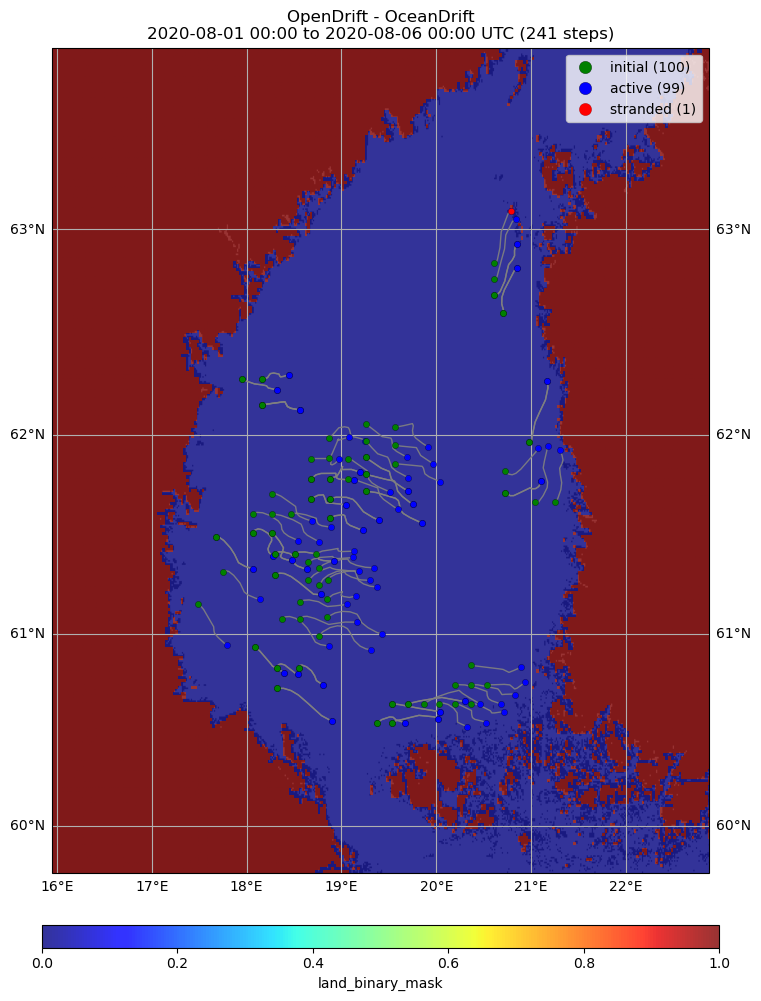

(<GeoAxes: title={'center': 'OpenDrift - OceanDrift\n2020-08-01 00:00 to 2020-08-06 00:00 UTC (241 steps)'}>,
 <Figure size 876.658x1100 with 2 Axes>)

In [20]:
o.plot(background='land_binary_mask',fast=True)
#o.plot(fast=True)

    FarmID  Country     Area_km2  N_turbines  \
0        1   Sweden   650.557150         166   
1        2   Sweden    35.633482          10   
2        3   Sweden    61.673642          14   
3        4   Sweden    50.788374          13   
4        5   Sweden   163.328594          39   
5        6   Sweden   615.838416         154   
6        7   Sweden   525.783028         134   
7        8   Sweden   487.077150         123   
8        9   Sweden   399.837660          92   
9       10   Sweden   525.258770         131   
10      11   Sweden  1193.974913         298   
11      12   Sweden   640.068889         157   
12      13  Finland  1227.527228         306   
13      14  Finland   128.207049          30   
14      15  Finland   201.731706          48   
15      16  Finland   210.040932          54   
16      17  Finland   176.199606          43   
17      18  Finland   179.078323          45   
18      19  Finland   274.191533          68   

                                       

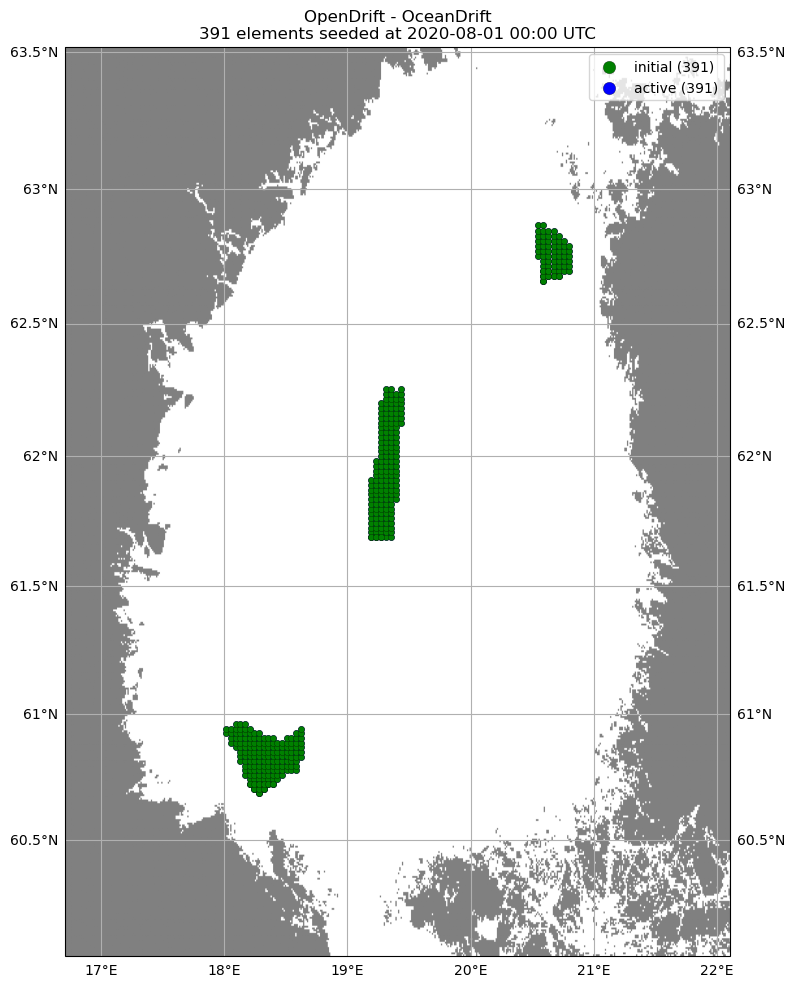

(<GeoAxes: title={'center': 'OpenDrift - OceanDrift\n391 elements seeded at 2020-08-01 00:00 UTC'}>,
 <Figure size 805.793x1100 with 1 Axes>)

In [3]:
gdf = gpd.read_file(data_file)
print(gdf)
o = OceanDrift(loglevel=50)
# add readers
o.add_reader(reader_grid, variables=['sea_floor_depth_below_sea_level','land_binary_mask'])
o.add_reader(reader_cmems, variables=['x_sea_water_velocity', 'y_sea_water_velocity'])        
# do not use auto landmask --> use landmask from reader
o.set_config('general:use_auto_landmask',  False)
o.set_config('general:coastline_action', 'stranding')

for i in [1, 12, 19]: #number of the wind farm
    row = gdf.loc[gdf['FarmID'] == i]
    loc = row.geometry
    number = int(row.N_turbines)    
    o.seed_from_geopandas(loc, number=number, time=starttime)

#o.run(duration=timedelta(days=duration),time_step=time_step,time_step_output=time_step_output)
o.plot(fast=True)